# Импорты

In [2]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

In [4]:
from pymatgen.analysis.eos import EOS

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar

from pymatgen.electronic_structure.core import Spin

In [5]:
pd.set_option('display.float_format', '{:.2e}'.format)

#### Импорт файлов серии расчетов

In [6]:
Ni3Al_INCAR = Incar.from_file("44/INCAR")

In [7]:
df_incar = pd.DataFrame({
    'Ni3Al': dict(Ni3Al_INCAR)
}).fillna('')

df_incar

,Ni3Al
SYSTEM,Ni3Al EOS
PREC,Accurate
NCORE,4
LREAL,False
LWAVE,False
LASPH,True
ADDGRID,True
SYMPREC,1.00e-05
ISYM,2
ISPIN,2


In [8]:
# a = 3.44
Ni3Al_44_Outcar = Outcar("44/result/OUTCAR")
Ni3Al_44_vasprun = Vasprun("44/result/vasprun.xml")

# a = 3.47
Ni3Al_47_Outcar = Outcar("47/result/OUTCAR")
Ni3Al_47_vasprun = Vasprun("47/result/vasprun.xml")

# a = 3.50
Ni3Al_50_Outcar = Outcar("50/result/OUTCAR")
Ni3Al_50_vasprun = Vasprun("50/result/vasprun.xml")

# a = 3.53
Ni3Al_53_Outcar = Outcar("53/result/OUTCAR")
Ni3Al_53_vasprun = Vasprun("53/result/vasprun.xml")

# a = 3.56
Ni3Al_56_Outcar = Outcar("56/result/OUTCAR")
Ni3Al_56_vasprun = Vasprun("56/result/vasprun.xml")

# a = 3.59
Ni3Al_59_Outcar = Outcar("59/result/OUTCAR")
Ni3Al_59_vasprun = Vasprun("59/result/vasprun.xml")

# a = 3.62
Ni3Al_62_Outcar = Outcar("62/result/OUTCAR")
Ni3Al_62_vasprun = Vasprun("62/result/vasprun.xml")

# a = 3.65
Ni3Al_65_Outcar = Outcar("65/result/OUTCAR")
Ni3Al_65_vasprun = Vasprun("65/result/vasprun.xml")

# a = 3.68
Ni3Al_68_Outcar = Outcar("68/result/OUTCAR")
Ni3Al_68_vasprun = Vasprun("68/result/vasprun.xml")

c:\Users\Akidra\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymatgen\io\vasp\outputs.py:1351: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
c:\Users\Akidra\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymatgen\io\vasp\outputs.py:1362: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


In [9]:
# run_01 - Al и Ni для вычисления энтальпии образования
Ni_01_Outcar = Outcar("../run_01/Ni/result/OUTCAR")
Al_01_Outcar = Outcar("../run_01/Al/result/OUTCAR")

In [10]:
outcars = [
    Ni3Al_44_Outcar,
    Ni3Al_47_Outcar,
    Ni3Al_50_Outcar,
    Ni3Al_53_Outcar,
    Ni3Al_56_Outcar,
    Ni3Al_59_Outcar,
    Ni3Al_62_Outcar,
    Ni3Al_65_Outcar,
    Ni3Al_68_Outcar
]

vaspruns = [
    Ni3Al_44_vasprun, Ni3Al_47_vasprun, Ni3Al_50_vasprun,
    Ni3Al_53_vasprun, Ni3Al_56_vasprun, Ni3Al_59_vasprun,
    Ni3Al_62_vasprun, Ni3Al_65_vasprun, Ni3Al_68_vasprun
]

a_values = [3.44, 3.47, 3.50, 3.53, 3.56, 3.59, 3.62, 3.65, 3.68]

In [11]:
df_kpoints = pd.DataFrame({
    'Система': ['Ni3Al'],
    'N k-точек': [len(vaspruns[0].actual_kpoints)],
    'K-меш': [f"{vaspruns[0].kpoints.kpts[0][0]}×{vaspruns[0].kpoints.kpts[0][1]}×{vaspruns[0].kpoints.kpts[0][2]}"]
})
df_kpoints

,Система,N k-точек,K-меш
0,Ni3Al,220,18×18×18


# Проверка сходимости электронного и ионного цикла

In [12]:
pd.set_option('display.float_format', '{:3}'.format)

df_stats = pd.DataFrame([
    {**outcar.run_stats, 'a': a} 
    for a, outcar in zip(a_values, outcars)
])

df_stats = df_stats.set_index('a')
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores
a,,,,,,,
3.44,None,127524.0,85.124,8.216,74.602,82.817,24
3.47,None,128204.0,89.508,7.816,79.408,87.224,24
3.5,None,132872.0,545.748,25.435,255.146,280.581,24
3.53,None,126952.0,76.108,6.913,66.97,73.883,24
3.56,None,129472.0,79.778,7.101,70.32,77.421,24
3.59,None,135180.0,84.236,8.046,73.898,81.944,24
3.62,None,137512.0,82.414,7.73,71.979,79.709,24
3.65,None,134568.0,81.007,7.962,71.444,79.406,24
3.68,None,134788.0,84.254,8.399,74.146,82.544,24


## Электронный цикл

In [13]:
data = []
for a, vasp in zip(a_values, vaspruns):
    ionic_steps = vasp.ionic_steps
    if ionic_steps:
        last_ionic = ionic_steps[-1]
        electronic_steps = last_ionic['electronic_steps']
        for i in range(1, len(electronic_steps)):
            d = abs(electronic_steps[i]['e_fr_energy'] - electronic_steps[i-1]['e_fr_energy'])
            data.append((a, i, d))

df_delta_e = pd.DataFrame(data, columns=['a (Å)', 'Итерация', '|ΔE| (эВ)'])
df_delta_e.style.hide(axis='index').format({'|ΔE| (эВ)': '{:.10f}'})

a (Å),Итерация,|ΔE| (эВ)
3.440000,1,180.1241796400
3.440000,2,4.5131495600
3.440000,3,0.0413421200
3.440000,4,0.0010016900
3.440000,5,0.0013992600
3.440000,6,4.1010778900
3.440000,7,0.0768476000
3.440000,8,0.0260961900
3.440000,9,0.0004500100
3.440000,10,0.0018825500


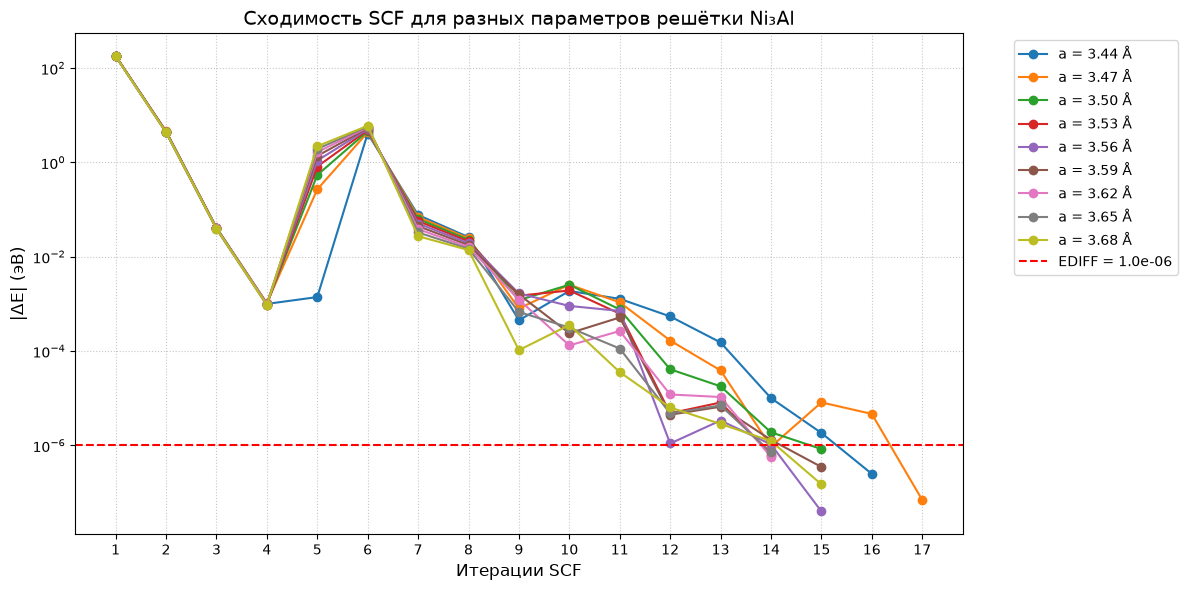

In [14]:
EDIFF = Ni3Al_INCAR.get('EDIFF')

plt.figure(figsize=(12, 6))

for a in sorted(df_delta_e['a (Å)'].unique()):
    sub = df_delta_e[df_delta_e['a (Å)'] == a]
    plt.plot(sub['Итерация'], sub['|ΔE| (эВ)'], 'o-', label=f'a = {a:.2f} Å')

plt.axhline(EDIFF, color='r', linestyle='--', label=f'EDIFF = {EDIFF:.1e}')
plt.yscale('log')
plt.xlabel('Итерации SCF', fontsize=12)
plt.ylabel('|ΔE| (эВ)', fontsize=12)
plt.title('Сходимость SCF для разных параметров решётки Ni₃Al', fontsize=14)
plt.xticks(sorted(df_delta_e['Итерация'].unique()))

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Ионный цикл

In [15]:
data_ion_forces = []
for a, vasp in zip(a_values, vaspruns):
    for i, step in enumerate(vasp.ionic_steps):
        forces = step['forces']
        max_force = max(abs(f) for atom in forces for f in atom)
        data_ion_forces.append({
            'a (Å)': a,
            'Ионный шаг': i,
            '|F_max| (эВ/Å)': max_force
        })

df_ion_forces = pd.DataFrame(data_ion_forces)
df_ion_forces

,a (Å),Ионный шаг,|F_max| (эВ/Å)
0,3.44,0,0.0
1,3.47,0,0.0
2,3.5,0,0.0
3,3.53,0,0.0
4,3.56,0,0.0
5,3.59,0,0.0
6,3.62,0,0.0
7,3.65,0,0.0
8,3.68,0,0.0


# Уравнение состояния

In [16]:
energies = [out.final_energy for out in outcars]  # total energy (эВ)
volumes = [a**3 for a in a_values] # ISIF=2

eos = EOS(eos_name='birch_murnaghan')
fit = eos.fit(volumes, energies)

v0 = fit.v0
e0 = fit.e0
b0 = fit.b0
b0_GPa = fit.b0_GPa
b1 = fit.b1
a0 = v0 ** (1/3)

print(f"Равновесный объём V0 = {v0:.4f} Å³")
print(f"Минимальная энергия E0 = {e0:.6f} эВ")
print(f"Объёмный модуль упругости B0 = {b0_GPa:.2f} ГПа")
print(f"Производная B0' (dK/dP) = {b1:.3f}")
print(f"Равновесный параметр решётки a0 = {a0:.4f} Å")

Равновесный объём V0 = 45.5442 Å³
Минимальная энергия E0 = -22.216574 эВ
Объёмный модуль упругости B0 = 178.89 ГПа
Производная B0' (dK/dP) = 4.622
Равновесный параметр решётки a0 = 3.5712 Å


![Скриншот](./DOI_10.1088_1757-899X_338_1_012041.png)
`DOI: DOI 10.1088/1757-899X/338/1/012041`: В Таблице 3 для Ni₃Al теоретическими строками являются значения, полученные методами GGA и LDA в цитируемой работе, а также данные из источников [15] и [16], которые в тексте прямо обозначены как расчётные. Экспериментальными строками служат значения из источников [17] и [18].

Полученные значения ($a_0 = 3.5712$ Å, $V_0 = 45.5442$ Å³, $B_0 = 178.89$ ГПа, $B_0' = 4.622$) сопоставлены с данными таблицы 3. При округлении $a_0$ до трёх значащих цифр (3.57 Å) отклонение от экспериментального значения [17] ($a_0 = 3.57$ Å) составляет 0%, аналогично теоретическому результату [15]. По $V_0$ и $B_0$ наши данные демонстрируют меньшее расхождение с экспериментом [17]–[18] ($V_0 = 45.58$ Å³, $B_0 = 179.3$ ГПа): отклонения равны 0.08% и 0.23% соответственно, тогда как для литературных теоретических значений [15]–[16] ($V_0 = 45.65$ Å³, $B_0 = 182.0$ ГПа) эти отклонения составляют 0.15% и 1.51%. Таким образом, по $V_0$ и $B_0$ наши результаты точнее воспроизводят эксперимент.

# Изменение полной энергии системы от параметра решётки Ni₃Al

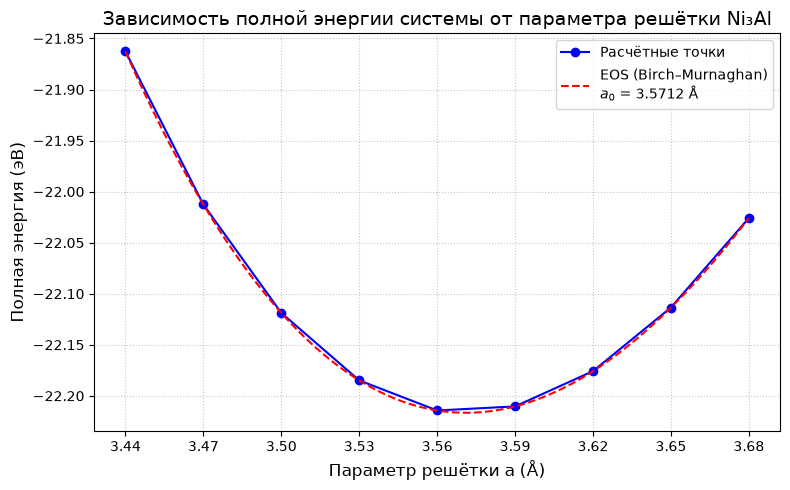

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(a_values, energies, marker='o', linestyle='-', color='b', label='Расчётные точки')

a_fit = np.linspace(min(a_values), max(a_values), 200)
v_fit = a_fit**3
eta = (v0 / v_fit) ** (2/3)
e_fit = e0 + (9/16) * b0 * v0 * ((eta - 1)**3 * b1 + (eta - 1)**2 * (6 - 4*eta))

plt.plot(a_fit, e_fit, 'r--', label=f'EOS (Birch–Murnaghan)\n$a_0$ = {a0:.4f} Å')
plt.xlabel('Параметр решётки a (Å)', fontsize=12)
plt.ylabel('Полная энергия (эВ)', fontsize=12)
plt.title('Зависимость полной энергии системы от параметра решётки Ni₃Al', fontsize=14)
plt.xticks(a_values)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Изменение магнитного момента от параметра решётки Ni₃Al

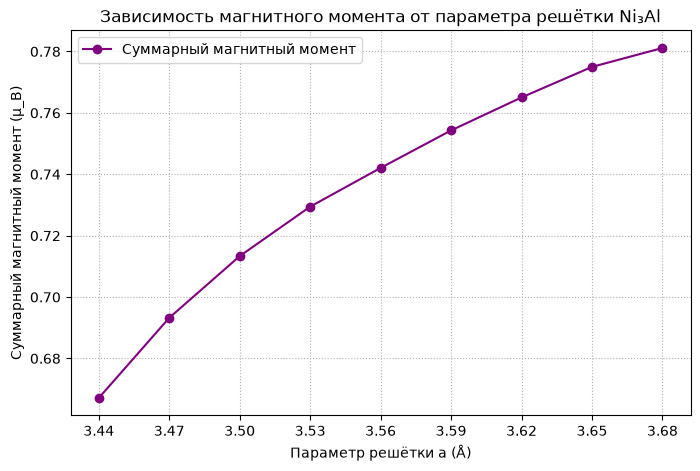

In [18]:
mag_moments = [out.total_mag for out in outcars] # total magnetization (μ_B)

plt.figure(figsize=(8,5))
plt.plot(a_values, mag_moments, 'o-', color='purple', label='Суммарный магнитный момент')
plt.xlabel('Параметр решётки a (Å)')
plt.ylabel('Суммарный магнитный момент (μ_B)')
plt.title('Зависимость магнитного момента от параметра решётки Ni₃Al')
plt.xticks(a_values)
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

# Изменение энтальпии образования от параметра решётки Ni₃Al

In [20]:
# Полные энергии на ячейку
TOTEN_Ni = Ni_01_Outcar.final_energy
TOTEN_Al = Al_01_Outcar.final_energy

E_Ni_atom = TOTEN_Ni / 4
E_Al_atom = TOTEN_Al / 4

print(f"E_Ni_atom = {E_Ni_atom:.6f} эВ")
print(f"E_Al_atom = {E_Al_atom:.6f} эВ")

E_Ni_atom = -5.572463 эВ
E_Al_atom = -3.746291 эВ


In [21]:
# Энергия образования на формульную единицу
E_form_fu = [e - (3*E_Ni_atom + E_Al_atom) for e in energies]

# Энергия образования на атом
E_form_at = [e/4.0 - (0.75*E_Ni_atom + 0.25*E_Al_atom) for e in energies]

df_eos = pd.DataFrame({
    'a (Å)': a_values,
    'E_Ni3Al (eV)': energies,
    'E_form (eV/fu)': E_form_fu,
    'E_form (eV/atom)': E_form_at
})
df_eos

,a (Å),E_Ni3Al (eV),E_form (eV/fu),E_form (eV/atom)
0,3.44,-21.86270175,-1.3990206249999986,-0.34975515624999964
1,3.47,-22.01260893,-1.5489278049999982,-0.38723195124999954
2,3.5,-22.11876122,-1.6550800949999989,-0.4137700237499997
3,3.53,-22.18486262,-1.7211814949999997,-0.43029537374999993
4,3.56,-22.21433732,-1.7506561949999977,-0.4376640487499994
5,3.59,-22.21034627,-1.746665144999998,-0.4366662862499995
6,3.62,-22.17582658,-1.7121454549999982,-0.42803636374999954
7,3.65,-22.11349151,-1.6498103849999985,-0.41245259624999964
8,3.68,-22.02587117,-1.5621900449999977,-0.3905475112499994


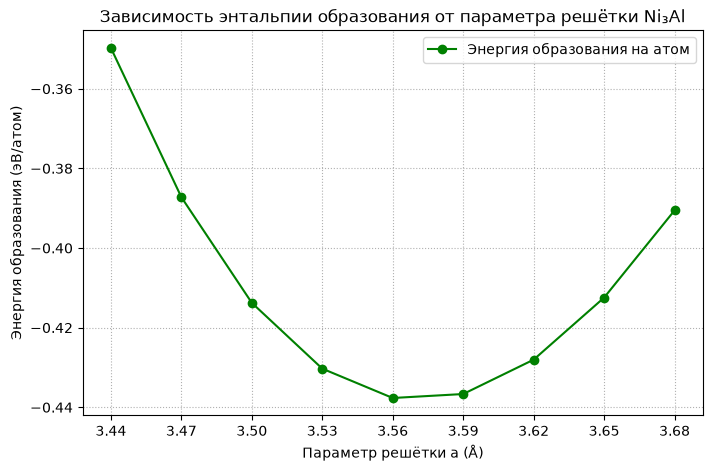

In [22]:
plt.figure(figsize=(8,5))
plt.plot(a_values, E_form_at, 'o-', color='green', label='Энергия образования на атом')
plt.xlabel('Параметр решётки a (Å)')
plt.ylabel('Энергия образования (эВ/атом)')
plt.title('Зависимость энтальпии образования от параметра решётки Ni₃Al')
plt.xticks(a_values)
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

# Плотность состояний (DOS)

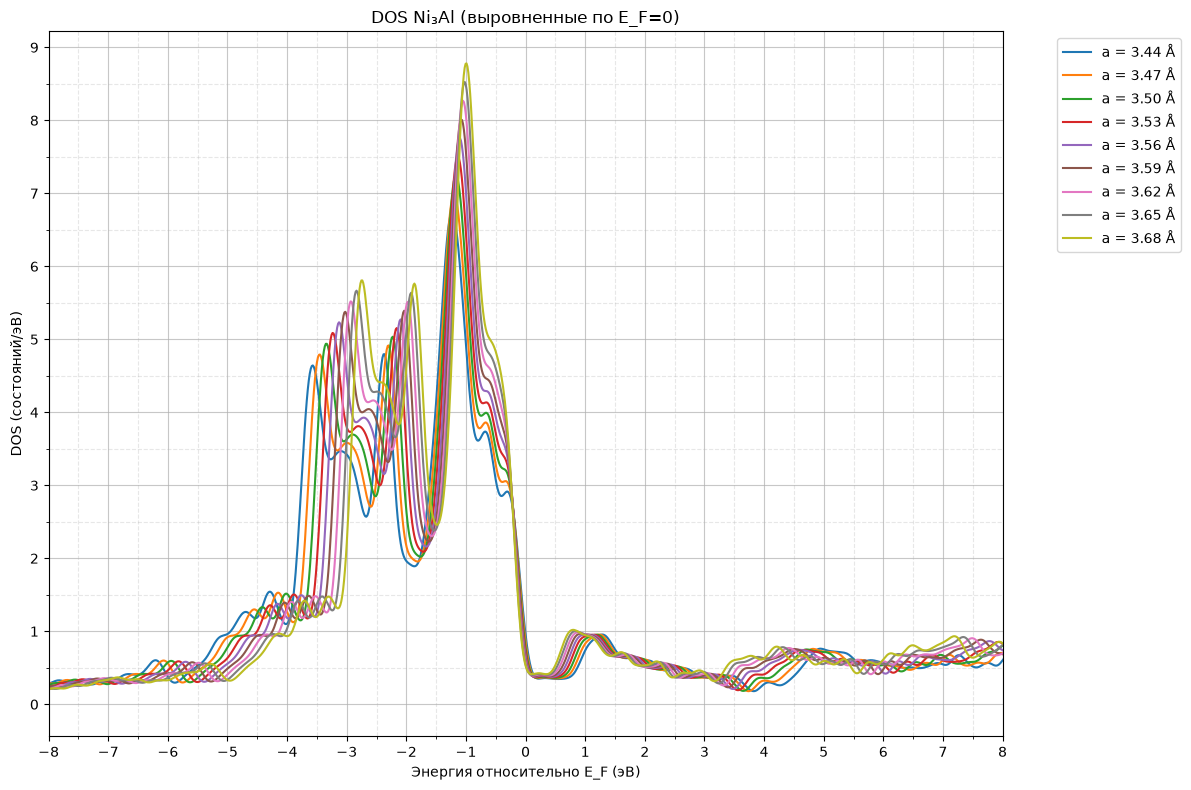

In [23]:
plt.figure(figsize=(12, 8))

for a, vasp, out in zip(a_values, vaspruns, outcars):
    dos = vasp.complete_dos
    energies = dos.energies
    densities = dos.densities[Spin.up]
    efermi = out.efermi
    plt.plot(energies - efermi, densities, label=f'a = {a:.2f} Å')

plt.xlabel('Энергия относительно E_F (эВ)')
plt.ylabel('DOS (состояний/эВ)')
plt.title('DOS Ni₃Al (выровненные по E_F=0)')
plt.xlim(-8, 8)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

plt.grid(which='major', alpha=0.7, linestyle='-')
plt.grid(which='minor', alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()